In [191]:
from matplotlib.pylab import plt
import numpy as np
import cv2

### Import Library
import library numpy untuk array, matplotlib untuk menyimpan gambar dan menampilkan, cv2 untuk membuat grayscale

### MENAMPILKAN GAMBAR AWAL
Membaca gambar dengan plt.imread kemudian disimpan di variabel meledak. Tampilkan gambar dengan plt.imshow disertai parameter cmap = 'gray'

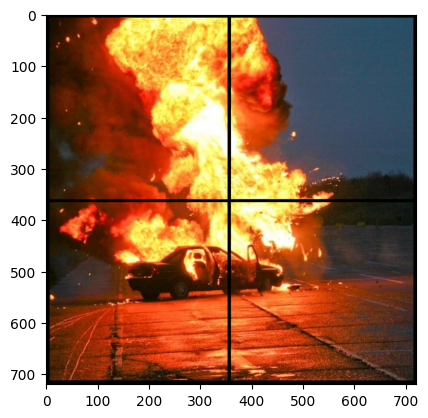

In [192]:
meledak = plt.imread('Assets/meledak.png')
plt.imshow(meledak)

### POTONG GAMBAR
Hasil cropping di simpan dalam variabel.
[5:360, 5:350] artinya ambil baris ke-5 sampai 360 dan kolom ke-5 sampai 350.
Ini berarti gambar hasil hanya akan berisi gambar dari rentang baris yang telah dipilih, membuang baris dan kolom diluar yang dipilih

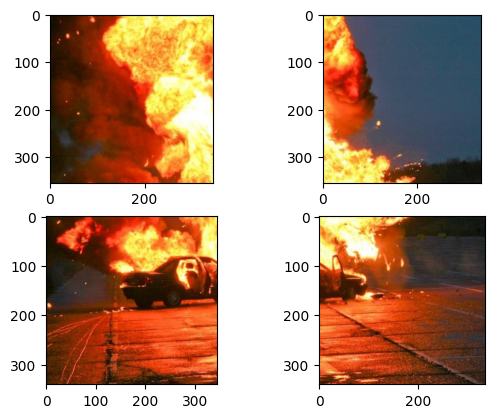

In [193]:
citra1 = meledak [5:360, 5:350, :]
plt.subplot(2, 2, 1)
plt.imshow(citra1)

citra2 = meledak [5:360, 365:700, :]
plt.subplot(2, 2, 2)
plt.imshow(citra2)

citra3 = meledak [370:710, 5:350, :]
plt.subplot(2, 2, 3)
plt.imshow(citra3)

citra4 = meledak [370:710, 365:700, :]
plt.subplot(2, 2, 4)
plt.imshow(citra4)
plt.show()

In [194]:
# Tipe b: penyatuan sumbu horizontal (ke samping)
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    
    if len(c1.shape) == 3:
        hasil = np.zeros((tinggi, lebar, c1.shape[2]), dtype=c1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

# Tipe c: penyatuan sumbu vertikal (atas-bawah)
def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    
    if len(c1.shape) == 3:
        hasil = np.zeros((tinggi, lebar, c1.shape[2]), dtype=c1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

### MERGE
Fungsi fungsi_dua_b dan fungsi_dua_c digunakan untuk menggabungkan dua citra menggunakan NumPy, di mana fungsi_dua_b menyatukan citra secara horizontal (ke samping) dengan menjumlahkan lebar keduanya, sedangkan fungsi_dua_c menyatukan citra secara vertikal (atas-bawah) dengan menjumlahkan tingginya. Kedua fungsi ini bekerja dengan membuat kanvas kosong (np.zeros) yang dimensinya disesuaikan dengan ukuran maksimal dan total citra input, lalu menggunakan teknik slicing array untuk menempatkan data pixel citra pertama dan kedua ke posisi yang tepat tanpa mengubah format warna maupun tipe data aslinya.

### Menampilkan Gambar yang Sudah di Merge Secara Horizontal dan Vertikal

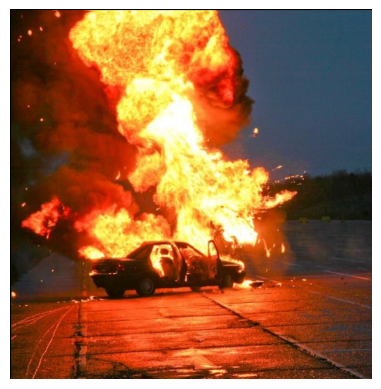

In [195]:
merger1 = fungsi_dua_b (citra1, citra2)
merger2 = fungsi_dua_b (citra3, citra4)
mergered = fungsi_dua_c (merger1, merger2)

plt.imshow(mergered)
plt.axis('off')

plt.show()

In [196]:
def ekualisasi_histogram(citra):
    if citra.dtype != np.uint8:
        if citra.max() <= 1.0:
            citra = (citra * 255).astype(np.uint8)
        else:
            citra = citra.astype(np.uint8)

    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    akumulasi = 0
    for i in range(256):
        akumulasi += histogram[i]
        cdf[i] = akumulasi

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    denominator = (panjang * lebar) - cdf_min
    
    if denominator == 0:
        cdf_norm = cdf
    else:
        cdf_norm = np.round((cdf - cdf_min) / denominator * 255).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

### EKUALISASI HISTOGRAM
Fungsi ekualisasi_histogram ini bertujuan untuk meningkatkan kontras citra dengan meratakan distribusi intensitas piksel melalui perhitungan Cumulative Distribution Function (CDF). Proses diawali dengan memastikan citra bertipe uint8, kemudian menghitung histogram frekuensi tiap nilai piksel dan mengakumulasikannya menjadi nilai CDF. Selanjutnya, nilai CDF dinormalisasi menggunakan rumus standar ekualisasi agar tersebar merata dalam rentang 0–255, dan akhirnya nilai piksel asli dipetakan kembali ke nilai hasil normalisasi tersebut untuk menghasilkan citra dengan detail yang lebih jelas.

### Menampilkan Gambar Hasil Ekualisasi

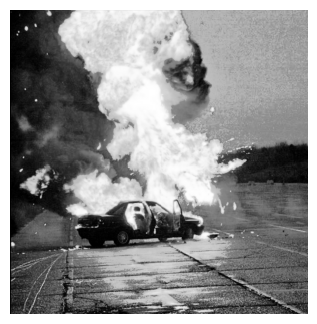

In [197]:
if len(mergered.shape) == 3:
    equal = cv2.cvtColor(mergered, cv2.COLOR_BGR2GRAY)

equal = ekualisasi_histogram(equal)

plt.subplot(1, 2, 1)
plt.imshow(equal, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [198]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

### HISTIGRAM
Fungsi buat_hist dan plot_histogram digunakan untuk menghitung serta memvisualisasikan sebaran frekuensi nilai piksel pada suatu citra. Fungsi buat_hist bekerja dengan menelusuri setiap koordinat piksel untuk menghitung kemunculan nilai intensitas (0–255) yang kemudian disimpan ke dalam sebuah daftar (list), sedangkan fungsi plot_histogram menggunakan pustaka Matplotlib untuk menampilkan data tersebut dalam bentuk diagram batang (bar chart) dengan kustomisasi judul, label sumbu, serta warna sesuai dengan parameter yang diberikan.

### Menampilkan Histogram

In [199]:
data_awal = mergered.copy()
if data_awal.max() <= 1.0:
    data_awal = (data_awal * 255).astype(np.uint8)
else:
    data_awal = data_awal.astype(np.uint8)

data_akhir = equal.astype(np.uint8)

h_awal = buat_hist(data_awal)
h_akhir = buat_hist(data_akhir)

plt.bar(range(256), h_akhir, color='red', alpha=0.5, label='Histogram Sesudah Ekualisasi', width=1.0)
plt.bar(range(256), h_awal, color='green', alpha=0.5, label='Histogram Sebelum Ekualisasi', width=1.0)

puncak_awal = max(h_awal[1:]) 
puncak_akhir = max(h_akhir[1:])
batas_y = max(puncak_awal, puncak_akhir) 

plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.legend(loc='upper right')

plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

### Menampilkan gambar windut dan bunga

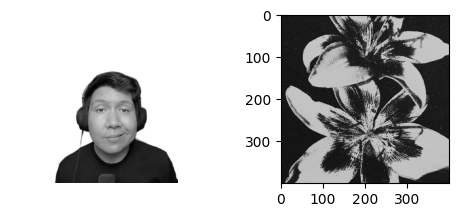

In [ ]:
windut = plt.imread('Assets/Windut.png')
windut = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)

bunga = plt.imread('Assets/Bunga.png')

plt.subplot(2, 2, 1)
plt.imshow(windut, cmap = 'gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bunga, cmap = 'gray')

In [ ]:
def spesifikasi_histogram(citra_asal, citra_target): 
   
    if citra_asal.max() <= 1.0 and citra_asal.dtype != np.uint8:
        citra_asal = (citra_asal * 255).astype(np.uint8)
    else:
        citra_asal = citra_asal.astype(np.uint8)

    if citra_target.max() <= 1.0 and citra_target.dtype != np.uint8:
        citra_target = (citra_target * 255).astype(np.uint8)
    else:
        citra_target = citra_target.astype(np.uint8)

    hist_asal = np.zeros(256, dtype=int) 
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1
    
    hist_target = np.zeros(256, dtype=int) 
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 

    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]

    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 

    map_hist = np.zeros(256, dtype=np.uint8) 
    for i in range(256):
        selisih = np.abs(cdf_asal[i] - cdf_target)
        j_terdekat = np.argmin(selisih)
        map_hist[i] = j_terdekat

    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil 

### SPESIFIKASI HISTOGRAM
Fungsi spesifikasi_histogram bertujuan untuk mengubah distribusi warna citra asal agar mengikuti pola distribusi citra target melalui teknik histogram matching. Proses dimulai dengan normalisasi kedua citra ke tipe uint8, dilanjutkan dengan perhitungan histogram serta nilai akumulasi Cumulative Distribution Function (CDF) yang telah dinormalisasi untuk masing-masing citra. Inti dari fungsi ini adalah pembuatan tabel pemetaan (mapping table) yang mencari nilai intensitas terdekat antara CDF asal dan CDF target, kemudian setiap piksel pada citra asal dipetakan ulang menggunakan tabel tersebut sehingga menghasilkan citra baru yang memiliki karakteristik visual atau kontras serupa dengan citra target.

### Menampilkan Hasil Spesifikasi

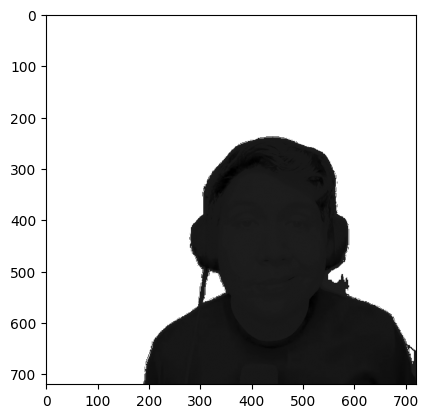

In [ ]:
windut_spesifikasi = spesifikasi_histogram(windut, bunga)

plt.imshow(windut_spesifikasi, cmap='gray')
plt.show()

### Menampilkan Histogram Hasil Spesifikasi

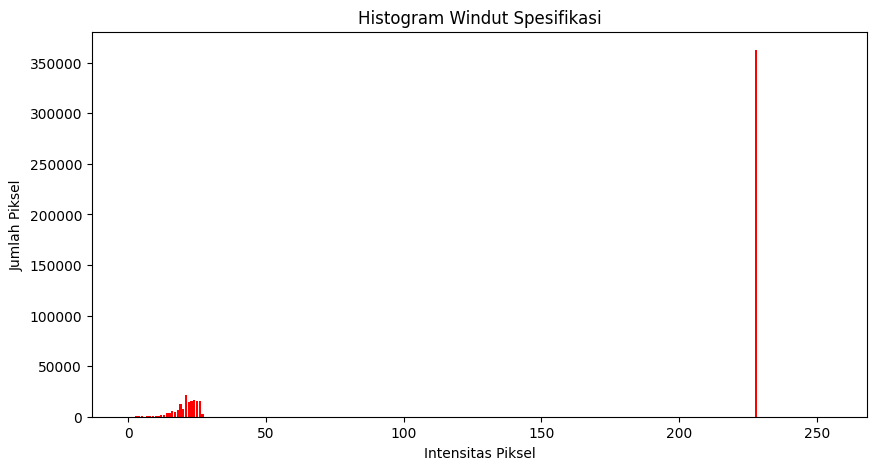

In [ ]:
hist_data = buat_hist(windut_spesifikasi)

plot_histogram(hist_data, "Histogram Windut Spesifikasi", "red")


In [ ]:
def merge_image(citra1, citra2, orientation='H'): 
    if citra1 is None or citra2 is None:
        return None

    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
    
    return gabungan

### MERGE
Fungsi merge_image digunakan untuk menggabungkan dua citra menjadi satu kanvas baru dengan pilihan orientasi horizontal ('H') atau vertikal, di mana fungsi ini secara otomatis menghitung dimensi total yang diperlukan dan menyiapkan wadah kosong (np.zeros) yang mendukung format grayscale maupun berwarna. Proses penyatuan dilakukan dengan menempatkan citra pertama pada titik awal koordinat, kemudian menempelkan citra kedua tepat di samping atau di bawah citra pertama menggunakan teknik slicing array, sehingga menghasilkan satu citra gabungan yang tetap mempertahankan tipe data asli dari citra inputnya.

### Menampilkan hasil

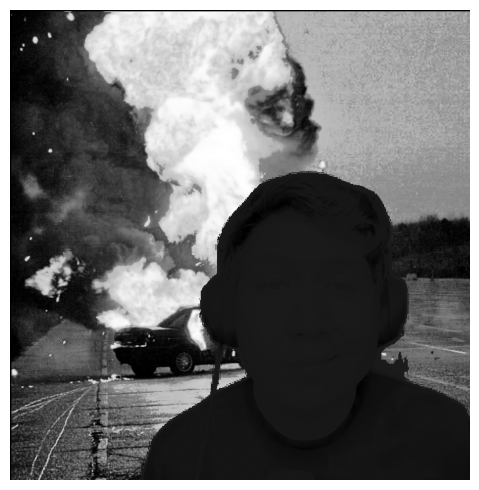

In [ ]:
background = equal.astype(np.uint8)
siluet = windut_spesifikasi.astype(np.uint8)

h = min(background.shape[0], siluet.shape[0])
w = min(background.shape[1], siluet.shape[1])

background_crop = background[:h, :w]
siluet_crop = siluet[:h, :w]

hasil = np.zeros_like(background_crop, dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if siluet_crop[i, j] < 128: 
            hasil[i, j] = siluet_crop[i, j]
        else:
            hasil[i, j] = background_crop[i, j]

plt.figure(figsize=(15, 5))

plt.subplot(1, 1, 1)
plt.imshow(hasil, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Menampilkan Hasil Penggabungan 2 Citra

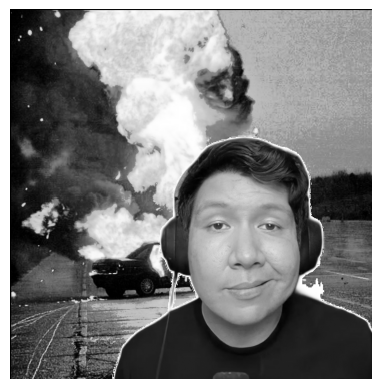

In [ ]:
windut_asli = cv2.imread('Assets/Windut.png', 0) 

bg = equal.astype(np.uint8) 
mask = windut_spesifikasi.astype(np.uint8) 

h = min(bg.shape[0], mask.shape[0], windut_asli.shape[0])
w = min(bg.shape[1], mask.shape[1], windut_asli.shape[1])

bg_c = bg[:h, :w]
mask_c = mask[:h, :w]
wajah_c = windut_asli[:h, :w]

hasil_final = np.zeros_like(bg_c)
for i in range(h):
    for j in range(w):
        if mask_c[i, j] < 128: 
            hasil_final[i, j] = wajah_c[i, j]
        else:
            hasil_final[i, j] = bg_c[i, j]

plt.imshow(hasil_final, cmap='gray')
plt.axis('off')
plt.show()

### Menampilkan Hasil Spesifikasi

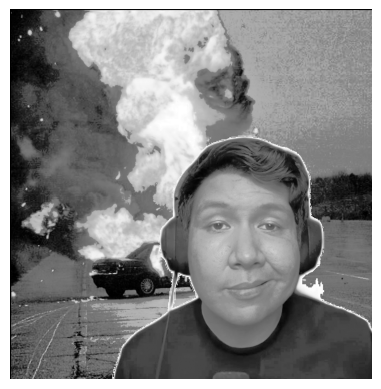

In [ ]:
langit_img = cv2.imread('Assets/Langit.png') 
langit_gray = cv2.cvtColor(langit_img, cv2.COLOR_BGR2GRAY)

def histogram_specification(source, reference):
    s_values, bin_idx, s_counts = np.unique(source.ravel(), return_inverse=True, return_counts=True)
    s_quantiles = np.cumsum(s_counts).astype(np.float64)
    s_quantiles /= s_quantiles[-1]
    
    r_values, r_counts = np.unique(reference.ravel(), return_counts=True)
    r_quantiles = np.cumsum(r_counts).astype(np.float64)
    r_quantiles /= r_quantiles[-1]
    
    interp_values = np.interp(s_quantiles, r_quantiles, r_values)
    return interp_values[bin_idx].reshape(source.shape).astype(np.uint8)

final_ganteng = histogram_specification(hasil_final, langit_gray)

plt.subplot(1, 1, 1)
plt.imshow(final_ganteng, cmap='gray')
plt.axis('off')

plt.show()

### Menampilkan Histogram Hasil Spesifikasi

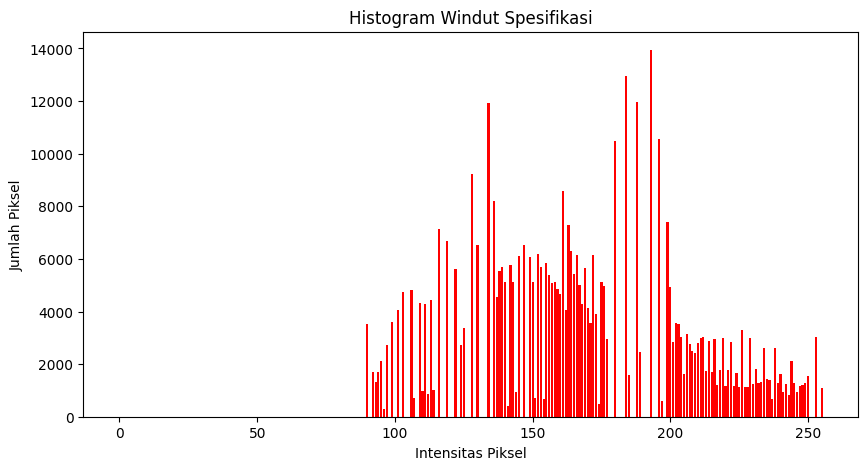

In [ ]:
hist_data = buat_hist(final_ganteng)

plot_histogram(hist_data, "Histogram Windut Spesifikasi", "red")

In [ ]:
meledak = plt.imread('Assets/meledak_biru.png')
windut = plt.imread('Assets/Windut.png')

print(meledak.shape)
print(windut.shape)


(1168, 1144, 4)
(720, 720, 3)


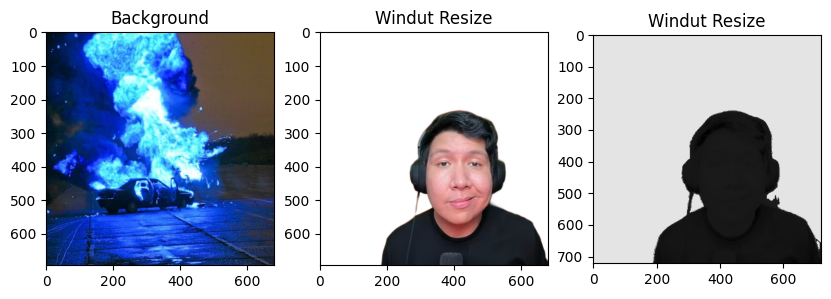

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img1 = mergered
img2 = cv2.imread('Assets/Windut.png')
img3 = windut_spesifikasi

# Ambil ukuran gambar pertama
tinggi = img1.shape[0]
lebar = img1.shape[1]

# Resize gambar kedua mengikuti gambar pertama
img2 = cv2.resize(img2, (lebar, tinggi))

# Tampilkan
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Background")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Windut Resize")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title("Windut Resize")

plt.show()

(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

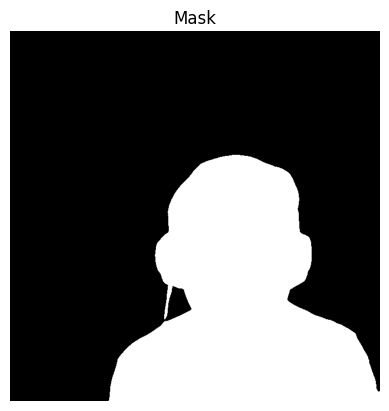

In [ ]:
tinggi = min(meledak.shape[0], windut.shape[0])
lebar = min(meledak.shape[1], windut.shape[1])

background_crop = meledak[:tinggi, :lebar].copy()
windut_crop = windut[:tinggi, :lebar].copy()
windut_gray = cv2.cvtColor(windut_crop, cv2.COLOR_BGR2GRAY)

if windut_gray.max() <= 1.0:
    thresh_val = 0.9
else:
    thresh_val = 240

_, mask = cv2.threshold(windut_gray, thresh_val, 255, cv2.THRESH_BINARY_INV)

mask_binary = (mask > 0).astype(np.uint8)

plt.imshow(mask * 255, cmap='gray')
plt.title("Mask")
plt.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


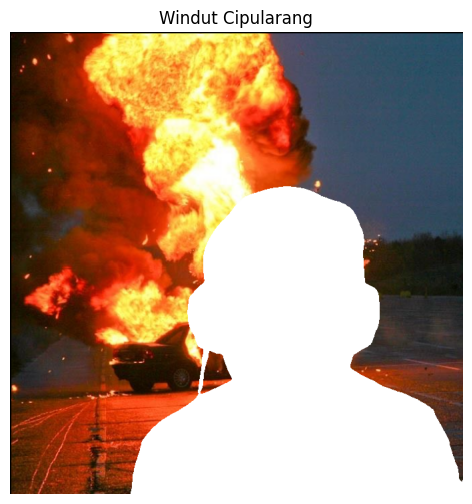

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Diasumsikan img1 dan img2 sudah memiliki ukuran yang sama dari proses sebelumnya
# img1 = background (meledak_biru), img2 = objek (Windut)

# 1. Ubah Windut ke Grayscale untuk proses masking
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

# 2. Tentukan nilai threshold berdasarkan skala pixel (0.0-1.0 atau 0-255)
if img2_gray.max() <= 1.0:
    thresh_val = 0.9
else:
    thresh_val = 240

# 3. Buat Masker
_, mask = cv2.threshold(img2_gray, thresh_val, 255, cv2.THRESH_BINARY_INV)
mask_binary = (mask > 0).astype(np.uint8)

# 4. Gabungkan Gambar menggunakan Masker
# Copy background sebagai dasar
hasil_warna = img1.copy()

# Tempelkan pixel img2 ke img1 hanya pada area masker
hasil_warna[mask_binary == 1] = img2[mask_binary == 1]

# 5. Tampilkan Hasil Akhir
plt.figure(figsize=(6, 6))

# Cek dimensi untuk menampilkan warna dengan benar
if len(hasil_warna.shape) == 3:
    plt.imshow(hasil_warna) # Langsung tampilkan jika sudah RGB
else:
    plt.imshow(hasil_warna)

plt.title("Windut Cipularang")
plt.axis("off")
plt.show()

In [ ]:
def tumpuk_depan_color(citra_hitam, citra_asli_color, citra_belakang_color):
    hasil = np.zeros((citra_belakang_color.shape[0], 
                      citra_belakang_color.shape[1], 3), dtype=np.uint8)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   # area hitam → wajah berwarna
                hasil[i, j] = citra_asli_color[i, j]
            else:                         # area putih → ledakan berwarna
                hasil[i, j] = citra_belakang_color[i, j]

    return hasil

windah_mel_color = tumpuk_depan_color(img3, img2, img1)

plt.imshow(windah_mel_color)  
plt.title("Windut Cipularang")
plt.show()

IndexError: index 680 is out of bounds for axis 1 with size 680